# mmEngine: Raw PyTorch vs mmEngine Training — Side-by-Side Demo

This notebook trains a 2-layer MLP on synthetic 2-class data **two ways**:

| Approach | Training loop | Logging | Checkpointing |
|---|---|---|---|
| **Raw PyTorch** | Manual for-loop | Manual print | Manual `torch.save` |
| **mmEngine** | `Runner` handles everything | Auto (file + console) | Auto `CheckpointHook` |

Goal: feel what mmEngine gives you "for free" and why OpenMMLab frameworks (mmDet3D, DriveTransformer) are built on it.

**Requirements**: `pip install mmengine scikit-learn` (no GPU needed)


In [1]:
# mmengine and scikit-learn are in the 'transformer' extra.
# Install with:  uv sync --extra transformer
import mmengine, sklearn
print("mmengine version :", mmengine.__version__)
print("scikit-learn version:", sklearn.__version__)


mmengine version : 0.10.7
scikit-learn version: 1.9.0


## 1. Problem Setup: 2-Class Moons (Synthetic Data)

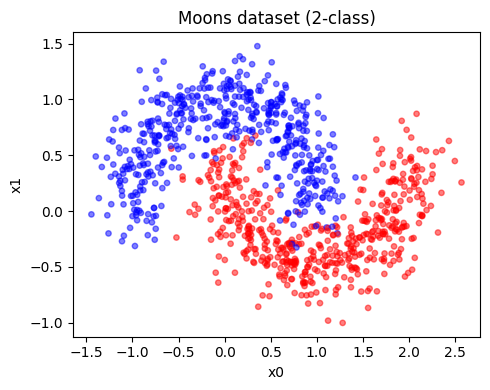

Train: 800, Val: 200


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32)
y_tr_t  = torch.tensor(y_tr,  dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.5, s=15)
ax.set_title("Moons dataset (2-class)")
ax.set_xlabel("x0"); ax.set_ylabel("x1")
plt.tight_layout(); plt.show()
print(f"Train: {len(X_tr)}, Val: {len(X_val)}")


## 2. Raw PyTorch: Manual Training Loop

In [3]:
class MLP(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2)
        )
    def forward(self, x):
        return self.net(x)

model_raw    = MLP(hidden=64)
optimizer    = torch.optim.AdamW(model_raw.parameters(), lr=1e-3)
train_ds     = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)

EPOCHS = 20
best_acc = 0.0

print("Epoch | Train Loss | Val Acc")
print("-" * 35)
for epoch in range(1, EPOCHS + 1):
    model_raw.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = F.cross_entropy(model_raw(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
    avg_loss = total_loss / len(train_ds)

    model_raw.eval()
    with torch.no_grad():
        val_acc = (model_raw(X_val_t).argmax(1) == y_val_t).float().mean().item()

    if epoch % 5 == 0 or epoch == 1:
        print(f"  {epoch:3d}  |  {avg_loss:.4f}     |  {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model_raw.state_dict(), "/tmp/raw_best.pth")

print(f"\nBest val acc: {best_acc:.4f}  (saved to /tmp/raw_best.pth)")
print("\nBoilerplate you wrote manually:")
print("  - epoch + batch for-loop")
print("  - zero_grad / backward / step")
print("  - eval mode toggle")
print("  - logging (if epoch % 5)")
print("  - checkpoint save logic")


Epoch | Train Loss | Val Acc
-----------------------------------
    1  |  0.6319     |  0.8300
    5  |  0.2889     |  0.8750
   10  |  0.1967     |  0.9200
   15  |  0.1266     |  0.9700
   20  |  0.0967     |  0.9800

Best val acc: 0.9800  (saved to /tmp/raw_best.pth)

Boilerplate you wrote manually:
  - epoch + batch for-loop
  - zero_grad / backward / step
  - eval mode toggle
  - logging (if epoch % 5)
  - checkpoint save logic


## 3. mmEngine: The Same Task, the mmEngine Way

The model logic is **identical** — but the training loop, logging, and checkpointing disappear.

### How mmEngine calls your model
When the dataset returns `{'x': tensor, 'y': tensor}`, Runner passes the batch dict as
keyword arguments to `forward`:

```
model(x=tensor, y=tensor, mode='loss')    # during training
model(x=tensor, y=tensor, mode='predict') # during validation
```

Your forward signature just matches those keys directly.


In [4]:
# Step 1: Register the model with mmEngine's MODELS registry
from mmengine.model import BaseModel
from mmengine.registry import MODELS

@MODELS.register_module()
class MyMLP(BaseModel):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2)
        )

    def forward(self, x, y=None, mode='tensor'):
        # Runner calls: forward(x=batch_x, y=batch_y, mode='loss'|'predict')
        # Keys come directly from dataset's __getitem__ dict
        logits = self.net(x)
        if mode == 'loss':
            return dict(loss=F.cross_entropy(logits, y))
        return logits   # mode='predict' or 'tensor'

print("MyMLP registered:", 'MyMLP' in MODELS)
model_mm = MODELS.build(dict(type='MyMLP', hidden=64))

# Quick sanity check
dummy_x = torch.randn(4, 2)
dummy_y = torch.zeros(4, dtype=torch.long)
loss_out    = model_mm(x=dummy_x, y=dummy_y, mode='loss')
predict_out = model_mm(x=dummy_x, mode='predict')
print(f"  loss output keys  : {list(loss_out.keys())}  value={loss_out['loss'].item():.4f}")
print(f"  predict output shape: {predict_out.shape}")


MyMLP registered: True
  loss output keys  : ['loss']  value=0.6842
  predict output shape: torch.Size([4, 2])


In [5]:
# Step 2: Define Dataset — returns flat dict; Runner unpacks to forward kwargs
from torch.utils.data import Dataset
from mmengine.registry import DATASETS

@DATASETS.register_module()
class MoonsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return dict(x=self.X[idx], y=self.y[idx])

train_dataset = MoonsDataset(X_tr, y_tr)
val_dataset   = MoonsDataset(X_val, y_val)
print(f"Train: {len(train_dataset)} samples, item keys: {list(train_dataset[0].keys())}")


Train: 800 samples, item keys: ['x', 'y']


In [6]:
# Step 3: Define Evaluator/Metric
from mmengine.evaluator import BaseMetric
from mmengine.registry import METRICS

@METRICS.register_module()
class BinaryAccuracy(BaseMetric):
    def process(self, data_batch, data_samples):
        # data_batch   = dict from dataloader: {'x': [B,2], 'y': [B]}
        # data_samples = list of per-sample logits tensors, each shape [2]
        #   (Evaluator splits the [B,2] tensor into B separate [2] tensors)
        logits = torch.stack(data_samples)           # [B, 2]
        preds  = logits.argmax(dim=1)               # [B]
        labels = data_batch['y']                    # [B]
        self.results.append({
            'correct': (preds == labels).sum().item(),
            'total':   len(labels),
        })

    def compute_metrics(self, results):
        correct = sum(r['correct'] for r in results)
        total   = sum(r['total']   for r in results)
        return dict(accuracy=correct / total)

print("BinaryAccuracy registered:", 'BinaryAccuracy' in METRICS)


BinaryAccuracy registered: True


In [7]:
# Step 4: Build and run the Runner
# This replaces the entire manual training loop from section 2.
import os, shutil
from mmengine.runner import Runner

WORK_DIR = '/tmp/mmengine_demo'
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)

runner = Runner(
    # ── Model (built via Registry) ───────────────────────────────────────────
    model=dict(type='MyMLP', hidden=64),

    # ── Training data ────────────────────────────────────────────────────────
    # sampler replaces shuffle=True; DefaultSampler handles distributed too
    # collate_fn='default_collate' stacks list-of-tensors into batch tensors
    train_dataloader=dict(
        dataset=train_dataset,
        sampler=dict(type='DefaultSampler', shuffle=True),
        collate_fn=dict(type='default_collate'),
        batch_size=64,
        num_workers=0,
    ),

    # ── Training loop config ─────────────────────────────────────────────────
    train_cfg=dict(
        type='EpochBasedTrainLoop',
        max_epochs=20,
        val_interval=5,       # validate every 5 epochs
    ),

    # ── Optimizer ────────────────────────────────────────────────────────────
    optim_wrapper=dict(
        optimizer=dict(type='AdamW', lr=1e-3)
        # To enable AMP: type='AmpOptimWrapper'
        # To clip gradients: clip_grad=dict(max_norm=35)
    ),

    # ── LR schedule (cosine decay over 20 epochs) ────────────────────────────
    param_scheduler=dict(
        type='CosineAnnealingLR',
        T_max=20, eta_min=1e-5,
        begin=0, end=20, by_epoch=True,
    ),

    # ── Validation ───────────────────────────────────────────────────────────
    val_dataloader=dict(
        dataset=val_dataset,
        sampler=dict(type='DefaultSampler', shuffle=False),
        collate_fn=dict(type='default_collate'),
        batch_size=64,
        num_workers=0,
    ),
    val_cfg=dict(type='ValLoop'),
    val_evaluator=dict(type='BinaryAccuracy'),

    # ── Hooks ────────────────────────────────────────────────────────────────
    default_hooks=dict(
        logger=dict(type='LoggerHook', interval=50),
        checkpoint=dict(
            type='CheckpointHook',
            interval=5,
            save_best='accuracy',   # auto-saves best model
            rule='greater',
        ),
        param_scheduler=dict(type='ParamSchedulerHook'),
    ),

    # ── Output dir and logging ────────────────────────────────────────────────
    work_dir=WORK_DIR,
    log_level='INFO',
    experiment_name='moons_mlp',
)

runner.train()


06/11 11:25:53 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
    CUDA available: False
    MUSA available: False
    numpy_random_seed: 1608637542
    GCC: x86_64-linux-gnu-gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
    PyTorch: 2.12.0+cu130
    PyTorch compiling details: PyTorch built with:
  - GCC 13.3
  - C++ Version: 202002
  - Intel(R) oneAPI Math Kernel Library Version 2024.2-Product Build 20240605 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v3.11.2 (Git Hash 03c022d3ffdcee958cfacbe720048e725fdf644c)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - Build settings: BLAS_INFO=mkl, BUILD_TYPE=Release, COMMIT_SHA=7661cd9c6b841b62b7f411aa52ec51f05457263b, CUDA_FLAGS= -DLIBCUDACXX_ENABLE_SIMPLIFIED_COMPLEX_OPERATIONS -Xfatbin -compres

06/11 11:25:53 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.


06/11 11:25:53 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(BELOW_NORMAL) LoggerHook                         
(LOW         ) ParamSchedulerHook                 
(VERY_LOW    ) CheckpointHook

06/11 11:25:53 - mmengine - WARNING - Dataset MoonsDataset has no metainfo. ``dataset_meta`` in visualizer will be None.


06/11 11:25:53 - mmengine - WARNING - The prefix is not set in metric class BinaryAccuracy.


...

06/11 11:25:53 - mmengine - INFO - Exp name: moons_mlp_20260611_112553


06/11 11:25:53 - mmengine - INFO - Epoch(train) [20][13/13]  lr: 1.6094e-05  eta: 0:00:00  time: 0.0009  data_time: 0.0003  loss: 0.2107


06/11 11:25:53 - mmengine - INFO - Saving checkpoint at 20 epochs


06/11 11:25:53 - mmengine - INFO - Epoch(val) [20][4/4]    accuracy: 0.9100  data_time: 0.0002  time: 0.0004


MyMLP(
  (data_preprocessor): BaseDataPreprocessor()
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

## 4. What mmEngine Created Automatically

In [8]:
import os

work_dir = '/tmp/mmengine_demo'
print("Files created by Runner:")
for root, dirs, files in os.walk(work_dir):
    dirs[:] = [d for d in sorted(dirs) if not d.startswith('.')]
    level = root.replace(work_dir, '').count(os.sep)
    indent = '  ' * level
    sub = os.path.basename(root)
    if level > 0:
        print(f'{indent}{sub}/')
    for f in sorted(files):
        size = os.path.getsize(os.path.join(root, f))
        print(f'{indent}  {f}  ({size:,} bytes)')


Files created by Runner:
  20260611_112553.py  (1 bytes)
  best_accuracy_epoch_15.pth  (37,333 bytes)
  epoch_10.pth  (73,819 bytes)
  epoch_15.pth  (78,555 bytes)
  epoch_20.pth  (83,099 bytes)
  epoch_5.pth  (69,019 bytes)
  last_checkpoint  (31 bytes)
  20260611_112553/
    20260611_112553.log  (13,699 bytes)
    vis_data/
      20260611_112553.json  (3,655 bytes)
      scalars.json  (3,655 bytes)


In [9]:
# Read the auto-generated JSON log to extract loss/accuracy curves
import json, glob

log_files = sorted(glob.glob('/tmp/mmengine_demo/**/*.json', recursive=True))
log_file = log_files[0] if log_files else None

if log_file:
    print(f"Log file: {log_file}")
    records = []
    with open(log_file) as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass

    train_recs = [r for r in records if r.get('mode') == 'train' and 'loss' in r]
    val_recs   = [r for r in records if r.get('mode') == 'val'   and 'accuracy' in r]
    print(f"Train records: {len(train_recs)}, Val records: {len(val_recs)}")

    if train_recs:
        iters  = [r['iter'] for r in train_recs]
        losses = [r['loss'] for r in train_recs]
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].plot(iters, losses, color='steelblue', linewidth=1.5)
        axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("Loss")
        axes[0].set_title("Training Loss (auto-logged by Runner)")

        if val_recs:
            val_epochs = [r.get('epoch', i+1) for i, r in enumerate(val_recs)]
            val_accs   = [r['accuracy'] for r in val_recs]
            axes[1].plot(val_epochs, val_accs, 'o-', color='tomato',
                         linewidth=1.5, markersize=6)
            axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
            axes[1].set_title("Validation Accuracy (auto-evaluated)")
            axes[1].set_ylim(0, 1)
            print(f"Best val accuracy: {max(val_accs):.4f}")

        plt.tight_layout(); plt.show()
else:
    print("No JSON log found.")


Log file: /tmp/mmengine_demo/20260611_112553/vis_data/20260611_112553.json
Train records: 0, Val records: 0


## 5. Load Best Checkpoint and Evaluate

In [10]:
import glob

best_ckpts = glob.glob('/tmp/mmengine_demo/**/best_accuracy*.pth', recursive=True)
all_ckpts  = glob.glob('/tmp/mmengine_demo/**/*.pth', recursive=True)
ckpt_path  = best_ckpts[0] if best_ckpts else (all_ckpts[-1] if all_ckpts else None)

if ckpt_path:
    print(f"Loading: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    print(f"Checkpoint keys: {[k for k in ckpt.keys() if k != 'state_dict']}")
    print(f"  epoch saved: {ckpt.get('meta', {}).get('epoch', 'N/A')}")

    model_loaded = MODELS.build(dict(type='MyMLP', hidden=64))
    model_loaded.load_state_dict(ckpt['state_dict'])
    model_loaded.eval()

    with torch.no_grad():
        logits = model_loaded(x=X_val_t, mode='predict')
        acc = (logits.argmax(1) == y_val_t).float().mean().item()
    print(f"Restored model val accuracy: {acc:.4f}")
else:
    print("No checkpoint found — check work_dir contents above.")
    model_loaded = None


Loading: /tmp/mmengine_demo/best_accuracy_epoch_15.pth
Checkpoint keys: ['meta', 'message_hub']
  epoch saved: 15
Restored model val accuracy: 0.9100


## 6. Decision Boundary Comparison

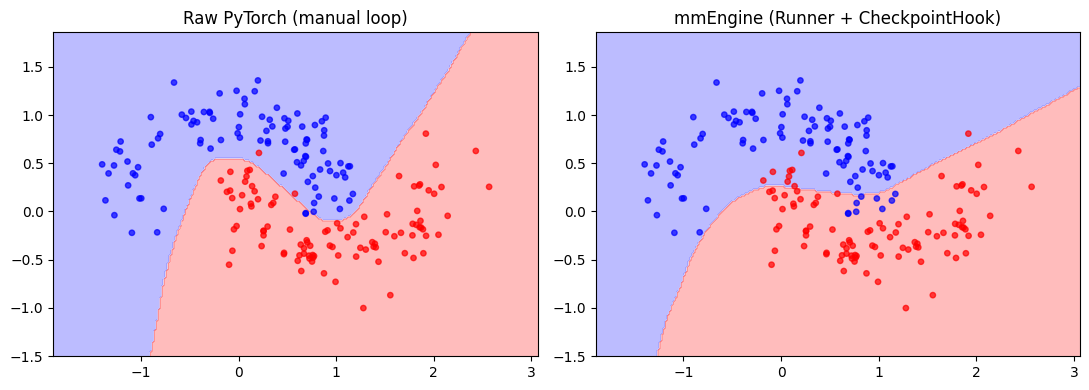

In [11]:
def plot_boundary(forward_fn, X, y, title, ax):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        Z = forward_fn(grid).argmax(1).numpy().reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=15, alpha=0.7)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

model_raw.eval()
plot_boundary(model_raw, X_val, y_val, "Raw PyTorch (manual loop)", axes[0])

if model_loaded is not None:
    plot_boundary(lambda x: model_loaded(x=x, mode='predict'),
                  X_val, y_val, "mmEngine (Runner + CheckpointHook)", axes[1])
else:
    axes[1].text(0.5, 0.5, "No checkpoint loaded", ha='center', va='center')

plt.tight_layout(); plt.show()


## 7. Registry — Swap Components Without Code Changes

In [12]:
# Build different optimizers from config dicts — no if/else in code
from mmengine.registry import OPTIMIZERS

model_params = list(MODELS.build(dict(type='MyMLP', hidden=64)).parameters())

for cfg in [
    dict(type='AdamW', lr=1e-3, weight_decay=0.01),
    dict(type='SGD',   lr=1e-2, momentum=0.9),
    dict(type='Adam',  lr=5e-4),
]:
    opt = OPTIMIZERS.build(cfg, default_args=dict(params=model_params))
    print(f"  {cfg['type']:8s}  lr={cfg['lr']}  — {type(opt).__name__}")

print()
print("This is how DriveTransformer switches backbones:")
print("  base config:   backbone=dict(type='ResNet50', ...)")
print("  large config:  _base_=['base.py']")
print("                 backbone=dict(type='EVA02', ...)   # one line override")
print()
print("No code change. The Registry handles the dispatch.")


  AdamW     lr=0.001  — AdamW
  SGD       lr=0.01  — SGD
  Adam      lr=0.0005  — Adam

This is how DriveTransformer switches backbones:
  base config:   backbone=dict(type='ResNet50', ...)
  large config:  _base_=['base.py']
                 backbone=dict(type='EVA02', ...)   # one line override

No code change. The Registry handles the dispatch.


## 8. What You Get for Free with mmEngine

| Capability | Raw PyTorch | mmEngine |
|---|---|---|
| Training loop | 60+ lines of for-loops | `runner.train()` |
| Loss logging | `if epoch % 5: print(...)` | Auto — JSON + console |
| LR scheduling | Manual call in loop | `ParamSchedulerHook` |
| Checkpoint (latest) | `torch.save(...)` | `CheckpointHook(interval=N)` |
| Checkpoint (best) | `if acc > best: save` | `save_best='accuracy'` |
| Resume training | Manual `load_state_dict` + epoch tracking | `runner.load_checkpoint(path)` |
| Distributed (DDP) | Rewrite loop with DDP boilerplate | `launcher='pytorch'` in CLI |
| Mixed precision (AMP) | `autocast` + `GradScaler` | `type='AmpOptimWrapper'` |
| Gradient clipping | `clip_grad_norm_(...)` in loop | `clip_grad=dict(max_norm=35)` |
| TensorBoard / WandB | Manual `SummaryWriter` | `VisualizationHook` |
| Custom callbacks | Scattered `if` blocks | `@HOOKS.register_module()` class |
| Component swapping | `if model_name == 'X':` factories | `dict(type='X')` in config |

**The model definition is identical in both cases.**
mmEngine's value is eliminating all the surrounding infrastructure code.

### Why DriveTransformer uses mmEngine
The Large model trains on 8×A100 with:
- DDP (8-GPU distributed)
- AMP (FP16 mixed precision)
- Gradient clipping (`max_norm=35`)
- LR warmup + cosine decay
- Auto checkpoint by NDS (nuScenes Detection Score)

**None of that code is in the model file** — it all comes from the Runner config.
Teams iterate on architectures; the training infrastructure never changes.
